# CCS3440 – SmartCare Hospital AI Coursework
## Task 03: Data Preprocessing & Feature Engineering
## Task 04: Exploratory Data Analysis (EDA)

**Target task:** Option C – Disease Risk Classification (`disease_risk_level`: Low / Medium / High)

**Author:** Ishini (Tasks 3 & 4)

This notebook cleans the raw `smartcare_ai_dataset_1000.csv`, engineers features, and produces
a model-ready train/test split (saved as CSVs) for the modelling team (Tasks 5–6) and the
explainability/prototype team (Tasks 7–8). Every transformation is justified, and the scaler is
fit on the training set only, to avoid data leakage into the test set.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Setup

In [3]:
# In Colab: click the folder icon on the left sidebar and upload
# smartcare_ai_dataset_1000.csv and smartcare_ai_dataset_data_dictionary.csv
# before running this cell.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

df_raw = pd.read_csv('smartcare_ai_dataset_1000.csv')
data_dict = pd.read_csv('smartcare_ai_dataset_data_dictionary.csv')
df = df_raw.copy()   # all transformations happen on this working copy; df_raw stays untouched for viva reference
df.shape


(1000, 33)

In [4]:
df.head()


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


---
# Task 03 - Data Preprocessing & Feature Engineering


## 3.1 Initial data quality check

In [5]:
df.info()
print("\nTarget distribution:")
print(df['disease_risk_level'].value_counts())
print(df['disease_risk_level'].value_counts(normalize=True).round(3) * 100)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   object 
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   object 
 4   blood_group                   1000 non-null   object 
 5   department                    1000 non-null   object 
 6   diagnosis                     1000 non-null   object 
 7   appointment_date              1000 non-null   object 
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   object 
 12  admitted                      1000 non-null   int64  
 13  room

## 3.2 Missing value handling

**Finding:** only `room_type` has missing values (906/1000 rows, 90.6%).

**Why one blanket fix is wrong here:** the missingness has two different causes:
- For **non-admitted patients** (`admitted == 0`), `room_type` is missing because no room was
  ever assigned - this is *Missing Not At Random* by design, not an error.
- For a further subset of **admitted patients** with a blank `room_type`, this is a genuine
  data-entry gap - *Missing At Random*.

**Decision:** handle each cause separately rather than filling everything the same way.
Non-admitted patients get an explicit `"Not Admitted"` category (this preserves information
instead of treating 90.6% of the dataset as "unknown"). Admitted-but-missing patients are
imputed with the mode room type among admitted patients - the least biased single-value
estimate available without extra data.

In [6]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nroom_type missing, broken down by admitted status:")
print(df.groupby('admitted')['room_type'].apply(lambda x: x.isnull().sum()))


Missing values per column:
room_type    906
dtype: int64

room_type missing, broken down by admitted status:
admitted
0    670
1    236
Name: room_type, dtype: int64


In [7]:
# Non-admitted -> explicit "Not Admitted" category (MNAR, not an error)
mask_not_admitted = (df['admitted'] == 0) & (df['room_type'].isnull())
df.loc[mask_not_admitted, 'room_type'] = 'Not Admitted'
print(f"Rows set to 'Not Admitted': {mask_not_admitted.sum()}")

# Admitted but missing -> impute with mode among admitted patients (MAR, true gap)
admitted_mode = df.loc[(df['admitted'] == 1) & (df['room_type'].notnull()), 'room_type'].mode()[0]
mask_admitted_missing = (df['admitted'] == 1) & (df['room_type'].isnull())
df.loc[mask_admitted_missing, 'room_type'] = admitted_mode
print(f"Rows imputed with mode ('{admitted_mode}'): {mask_admitted_missing.sum()}")

assert df['room_type'].isnull().sum() == 0, "room_type still has nulls!"
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")


Rows set to 'Not Admitted': 670
Rows imputed with mode ('General Ward'): 236

Remaining missing values: 0


## 3.3 Duplicate record detection

In [8]:
full_duplicates = df.duplicated().sum()
duplicate_record_ids = df['record_id'].duplicated().sum()
duplicate_patient_ids = df['patient_id'].duplicated().sum()  # informational only

print(f"Full-row duplicates: {full_duplicates}")
print(f"Duplicate record_id values: {duplicate_record_ids}")
print(f"Repeated patient_id values (expected — same patient, multiple visits, not an error): {duplicate_patient_ids}")

if full_duplicates > 0:
    df = df.drop_duplicates()
    print(f"Dropped {full_duplicates} duplicate rows.")


Full-row duplicates: 0
Duplicate record_id values: 0
Repeated patient_id values (expected — same patient, multiple visits, not an error): 0


## 3.4 Data cleaning - logical/physiological consistency checks

Beyond missing values, three concrete data-quality issues were checked for directly
(not just IQR-style statistical outliers, but values that are logically or physiologically
impossible):

| Issue | Rows found | Action | Justification |
|---|---|---|---|
| `missed_previous_appointments > previous_appointments` | 16 | Cap at `previous_appointments` | A patient cannot miss more appointments than they had |
| `systolic_bp <= diastolic_bp` | 3 | Swap the two values | Systolic must exceed diastolic physiologically; treated as a data-entry transposition rather than dropped |
| `treatments_count == 0` but `medicine_charge_lkr > 0` | 212 | No correction - documented only | A billing inconsistency unrelated to the clinical predictors used for the disease-risk task; out of scope to "fix" and would not affect this model |

No rows are dropped for any of these - corrections are applied in place to keep the full dataset.

In [9]:
# Issue 1: missed_previous_appointments cannot exceed previous_appointments
mask_bad_missed = df['missed_previous_appointments'] > df['previous_appointments']
print(f"Rows with impossible missed-appointment count: {mask_bad_missed.sum()}")
df.loc[mask_bad_missed, 'missed_previous_appointments'] = df.loc[mask_bad_missed, 'previous_appointments']
assert (df['missed_previous_appointments'] <= df['previous_appointments']).all()
print("Fixed: capped at previous_appointments.")


Rows with impossible missed-appointment count: 16
Fixed: capped at previous_appointments.


In [10]:
# Issue 2: systolic_bp must exceed diastolic_bp
mask_bad_bp = df['systolic_bp'] <= df['diastolic_bp']
print(f"Rows with invalid BP (systolic <= diastolic): {mask_bad_bp.sum()}")
print(df.loc[mask_bad_bp, ['record_id', 'systolic_bp', 'diastolic_bp']])

df.loc[mask_bad_bp, ['systolic_bp', 'diastolic_bp']] = \
    df.loc[mask_bad_bp, ['diastolic_bp', 'systolic_bp']].values

assert (df['systolic_bp'] > df['diastolic_bp']).all()
print("Fixed: swapped the two values for affected rows.")


Rows with invalid BP (systolic <= diastolic): 3
     record_id  systolic_bp  diastolic_bp
99         100           85            86
331        332           98           103
374        375           94            97
Fixed: swapped the two values for affected rows.


In [11]:
# Issue 3: treatments_count == 0 but medicine_charge_lkr > 0 -> documented, not corrected
mask_billing_inconsistency = (df['treatments_count'] == 0) & (df['medicine_charge_lkr'] > 0)
print(f"Billing inconsistency rows (documented only, not modified): {mask_billing_inconsistency.sum()}")
print("Rationale: unrelated to the clinical predictors for disease_risk_level — out of scope.")


Billing inconsistency rows (documented only, not modified): 212
Rationale: unrelated to the clinical predictors for disease_risk_level — out of scope.


## 3.5 Outlier identification (IQR method)

**Key decision - clinical outliers are identified but NOT removed or capped.** In a
disease-risk classification problem, an extreme value (very high cholesterol, very high BMI) is
very likely part of the *signal* that drives a "High" risk label, not noise. Removing it would
strip the model of the information it most needs to learn from.

In [12]:
def iqr_outlier_report(series, col_name):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"{col_name:22s} | bounds=({lower:.1f}, {upper:.1f}) | outliers={len(outliers)}")
    return outliers.index

clinical_cols = ['age', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi']

outlier_indices = {}
for col in clinical_cols:
    outlier_indices[col] = iqr_outlier_report(df[col], col)


age                    | bounds=(-3.0, 93.0) | outliers=0
systolic_bp            | bounds=(84.0, 172.0) | outliers=3
diastolic_bp           | bounds=(51.0, 107.0) | outliers=3
blood_sugar_mg_dl      | bounds=(44.5, 184.5) | outliers=10
cholesterol_mg_dl      | bounds=(105.0, 305.0) | outliers=6
bmi                    | bounds=(14.3, 36.7) | outliers=9


In [13]:
# Cross-check: do outliers skew toward the "High" risk class? Justifies KEEPING them.
for col in ['bmi', 'cholesterol_mg_dl']:
    idx = outlier_indices[col]
    if len(idx) > 0:
        print(f"\n{col} outlier rows — disease_risk_level distribution:")
        print(df.loc[idx, 'disease_risk_level'].value_counts())



bmi outlier rows — disease_risk_level distribution:
disease_risk_level
High      5
Medium    3
Low       1
Name: count, dtype: int64

cholesterol_mg_dl outlier rows — disease_risk_level distribution:
disease_risk_level
High      3
Medium    2
Low       1
Name: count, dtype: int64


## 3.6 Feature engineering

Raw vitals alone overlap heavily across Low/Medium/High risk (confirmed later in the EDA
section). Converting continuous vitals into clinically meaningful bands using standard medical
thresholds captures non-linear threshold effects that a plain numeric value doesn't expose, and
improves interpretability later for the Explainable AI stage (Task 07).

| New feature | Source | Bands used |
|---|---|---|
| `bp_category` | `systolic_bp`, `diastolic_bp` | Normal / Elevated / Hypertensive (AHA guidelines) |
| `bmi_category` | `bmi` | Underweight / Normal / Overweight / Obese (WHO bands) |
| `blood_sugar_category` | `blood_sugar_mg_dl` | Normal / Prediabetic / Diabetic |
| `age_group` | `age` | Child / Young Adult / Adult / Senior |
| `health_burden_score` | `previous_admissions` + `previous_appointments` | Composite numeric score of healthcare-system contact |


In [14]:
def bp_category(row):
    s, d = row['systolic_bp'], row['diastolic_bp']
    if s < 120 and d < 80:
        return 'Normal'
    elif s < 130 and d < 80:
        return 'Elevated'
    else:
        return 'Hypertensive'

def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

def blood_sugar_category(bs):
    if bs < 100:
        return 'Normal'
    elif bs < 126:
        return 'Prediabetic'
    else:
        return 'Diabetic'

def age_group(age):
    if age < 13:
        return 'Child'
    elif age < 30:
        return 'Young Adult'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'

df['bp_category'] = df.apply(bp_category, axis=1)
df['bmi_category'] = df['bmi'].apply(bmi_category)
df['blood_sugar_category'] = df['blood_sugar_mg_dl'].apply(blood_sugar_category)
df['age_group'] = df['age'].apply(age_group)
df['health_burden_score'] = df['previous_admissions'] + df['previous_appointments']

print(df[['bp_category', 'bmi_category', 'blood_sugar_category', 'age_group', 'health_burden_score']].head())


    bp_category bmi_category blood_sugar_category    age_group  \
0      Elevated   Overweight          Prediabetic        Adult   
1  Hypertensive        Obese             Diabetic  Young Adult   
2  Hypertensive   Overweight               Normal  Young Adult   
3  Hypertensive       Normal             Diabetic        Adult   
4  Hypertensive   Overweight               Normal        Adult   

   health_burden_score  
0                    2  
1                    3  
2                    8  
3                    1  
4                    5  


In [15]:
df_clean = df.copy()
df_clean.to_csv('smartcare_cleaned.csv', index=False)
print("Saved smartcare_cleaned.csv — readable version with engineered features, for EDA and report screenshots.")


Saved smartcare_cleaned.csv — readable version with engineered features, for EDA and report screenshots.


### 3.7 Target-leakage investigation

**Why this check is needed:** the reviewer flagged that 93.5% accuracy / 0.936 macro-F1 /
0.992 ROC-AUC is unusually high for 1,000 records, and asked the group to check *how*
`disease_risk_level` was generated. If the label was itself computed from `age`,
`blood_sugar_mg_dl`, `cholesterol_mg_dl`, `bmi`, and blood pressure (or bands derived from
them), then training on those same variables lets the model reconstruct the
label-generation rule rather than learn an independently generalisable pattern
(target / circular leakage).

**Method:** we cannot see the generator code, so we test the hypothesis empirically. A
simple, unweighted "risk flag count" is built purely from clinically-standard thresholds
(hypertensive BP, obese BMI, diabetic blood sugar, high cholesterol, senior age) and
compared with the actual label — with no fitting involved, just counting.

In [16]:
# itself introduce data leakage; it only tests whether the target LOOKS rule-generated.
risk_flags = (
    (df['bp_category'] == 'Hypertensive').astype(int) +
    (df['bmi_category'] == 'Obese').astype(int) +
    (df['blood_sugar_category'] == 'Diabetic').astype(int) +
    (df['age_group'] == 'Senior').astype(int) +
    (df['cholesterol_mg_dl'] > 240).astype(int)
)

from scipy.stats import spearmanr
def encode_risk_target(series):
    # Defensive: if this cell is re-run in a session where disease_risk_level was
    # already numerically encoded by an earlier run, mapping the string dict again
    # would silently produce NaN. Handle both cases so re-runs are safe.
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(int)
    return series.map({'Low': 0, 'Medium': 1, 'High': 2})
target_num = encode_risk_target(df['disease_risk_level'])
rho, p_value = spearmanr(risk_flags, target_num)
print(f"Spearman correlation between a naive 5-flag threshold score and disease_risk_level: "
      f"rho = {rho:.3f} (p = {p_value:.2e})")

print("\nMean flag count by actual risk class:")
display(
    pd.DataFrame({'risk_flags': risk_flags, 'disease_risk_level': df['disease_risk_level']})
      .groupby('disease_risk_level')['risk_flags'].describe()[['mean','std','min','max']]
      .reindex(['Low', 'Medium', 'High']).round(2)
)

# Naive threshold classifier from the flag count ALONE — no ML, no fitting
naive_pred = pd.cut(risk_flags, bins=[-1, 0, 2, 5], labels=[0, 1, 2]).astype(int)
from sklearn.metrics import accuracy_score, f1_score
print(f"\nA hand-written threshold rule on this single derived score alone reaches "
      f"accuracy = {accuracy_score(target_num, naive_pred):.3f}, "
      f"macro-F1 = {f1_score(target_num, naive_pred, average='macro'):.3f} "
      f"— with zero machine learning.")

Spearman correlation between a naive 5-flag threshold score and disease_risk_level: rho = 0.616 (p = 2.00e-105)

Mean flag count by actual risk class:


,mean,std,min,max
disease_risk_level,,,,
Low,0.56,0.53,0.0,2.0
Medium,1.21,0.73,0.0,3.0
High,2.28,0.99,0.0,5.0



A hand-written threshold rule on this single derived score alone reaches accuracy = 0.591, macro-F1 = 0.541 — with zero machine learning.


### 3.8 Feature selection (part 1)-Defining the prediction-time-safe feature set

**When is the prediction made?** For Option C to be a useful clinical-decision-support
tool, the risk score has to be available at patient intake / triage, before the
patient is admitted, before a room is assigned, before treatment starts and before the
bill is settled. Columns that only exist because the visit already happened a certain
way cannot be legitimate predictors — using them would mean the model needs to know the
outcome of the visit in order to predict risk at the start of the visit.

| Keep (known at intake) | Reason |
|---|---|
| `age`, `gender`, `blood_group` | Patient demographics, known before the visit |
| `department`, `diagnosis` | Recorded at triage/booking |
| `systolic_bp`, `diastolic_bp`, `blood_sugar_mg_dl`, `cholesterol_mg_dl`, `bmi` | Vitals measured at intake |
| `previous_appointments`, `missed_previous_appointments`, `previous_admissions` | Patient history prior to this visit — genuinely available beforehand |
| Engineered bands (`age_group`, `bp_category`, `bmi_category`, `blood_sugar_category`) | Derived only from the rows above |

| Drop — not available at prediction time | Reason |
|---|---|
| `appointment_status` | Only known once the appointment has concluded (Completed/No-show/Cancelled) |
| `admitted`, `room_type`, `length_of_stay_days` | Admission decision and outcome — happens *after* triage, would leak the downstream care pathway |
| `payment_status`, `payment_method`, all `*_charge_lkr`, `total_bill_lkr` | Billing is finalised at the end of the encounter, not at intake |
| `waiting_days`, `lab_tests_count`, `treatments_count` | Operational counts that accrue during/after the visit |
| `record_id`, `patient_id`, `appointment_date` | Identifiers / non-clinical |
| `no_show`, `readmitted_30_days` | Other AI targets — out of scope for Option C |

This table replaces the earlier "near-zero correlation" justification for dropping the
financial/operational columns.The decision here is made on domain/availability grounds only, before any statistic is computed from the data.

In [17]:
candidate_predictors_raw = [
    'age', 'gender', 'blood_group', 'department', 'diagnosis',
    'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi',
    'previous_appointments', 'missed_previous_appointments', 'previous_admissions',
]
candidate_predictors_category = [
    'gender', 'blood_group', 'department', 'diagnosis',
    'age_group', 'bp_category', 'bmi_category', 'blood_sugar_category',
    'previous_appointments', 'missed_previous_appointments', 'previous_admissions',
]
candidate_predictors_combined = list(dict.fromkeys(
    candidate_predictors_raw + ['age_group', 'bp_category', 'bmi_category', 'blood_sugar_category']
))

not_available_at_prediction_time = [
    'appointment_status', 'admitted', 'room_type', 'length_of_stay_days',
    'payment_status', 'payment_method', 'consultation_fee_lkr', 'room_charge_lkr',
    'lab_charge_lkr', 'medicine_charge_lkr', 'total_bill_lkr',
    'waiting_days', 'lab_tests_count', 'treatments_count',
    'record_id', 'patient_id', 'appointment_date', 'no_show', 'readmitted_30_days',
]
print(f"Raw candidate set:      {len(candidate_predictors_raw)} columns")
print(f"Category candidate set: {len(candidate_predictors_category)} columns")
print(f"Combined candidate set: {len(candidate_predictors_combined)} columns")
print(f"Excluded (not available at prediction time): {len(not_available_at_prediction_time)} columns")

Raw candidate set:      13 columns
Category candidate set: 11 columns
Combined candidate set: 17 columns
Excluded (not available at prediction time): 19 columns


### 3.9 Train/test split — done once, before any fitting
The split happens here, immediately after the candidate predictor sets are defined and
before anything is fit on the data — the feature-selection ablation below, the encoding,
and the scaling in Section 3.7 all reuse these same `train_idx`/`test_idx`, so nothing
downstream can leak test-set information back into a decision made on the training data.
This is a deliberate, standalone step rather than something folded into the ablation
experiment, so it stays a single, auditable checkpoint the rest of the notebook builds on.

In [18]:
target_num = encode_risk_target(df['disease_risk_level'])  # defined in the leakage-check cell above

train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=target_num
)
print(f"Train rows: {len(train_idx)}   Test rows: {len(test_idx)}")
print("\nClass distribution — train (%):")
print((target_num.loc[train_idx].value_counts(normalize=True).sort_index() * 100).round(1))
print("\nClass distribution — test (%):")
print((target_num.loc[test_idx].value_counts(normalize=True).sort_index() * 100).round(1))

Train rows: 800   Test rows: 200

Class distribution — train (%):
disease_risk_level
0    13.1
1    46.9
2    40.0
Name: proportion, dtype: float64

Class distribution — test (%):
disease_risk_level
0    13.0
1    47.0
2    40.0
Name: proportion, dtype: float64


### 3.10 Feature selection(part 2)-Ablation study — raw vs. engineered-category vs. combined features

The earlier draft asserted that engineered categorical bands "outperform" raw variables,
and combined both raw and category features for Logistic Regression, without a controlled
experiment — and mixing raw values with their own derived bands (e.g. `bmi` with
`bmi_category`) is redundant information that inflates multicollinearity for a linear
model. This section runs the missing experiment: the same model (Logistic Regression),
the same cross-validation, three different feature sets, evaluated only on the training
partition so the test set stays untouched for final evaluation later.

In [19]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# train_idx / test_idx / target_num were fixed once in Section 3.6d above and are reused here unchanged.

def build_pipeline(cols):
    numeric_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    categorical_cols = [c for c in cols if not pd.api.types.is_numeric_dtype(df[c])]
    ct = ColumnTransformer([
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
    ])
    return Pipeline([('prep', ct), ('clf', LogisticRegression(class_weight='balanced',
                                                                max_iter=2000, random_state=RANDOM_STATE))])

ablation_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ablation_results = []
feature_sets = {
    'raw-only': candidate_predictors_raw,
    'category-only': candidate_predictors_category,
    'combined': candidate_predictors_combined,
}
for name, cols in feature_sets.items():
    pipe = build_pipeline(cols)
    X_ablate = df.loc[train_idx, cols]
    y_ablate = target_num.loc[train_idx]
    scores = cross_val_score(pipe, X_ablate, y_ablate, cv=ablation_cv, scoring='f1_macro', n_jobs=-1)
    ablation_results.append({'feature_set': name, 'n_raw_columns': len(cols),
                              'cv_macro_f1_mean': scores.mean(), 'cv_macro_f1_std': scores.std()})

ablation_df = pd.DataFrame(ablation_results).sort_values('cv_macro_f1_mean', ascending=False).reset_index(drop=True)
ablation_df.round(4)

,feature_set,n_raw_columns,cv_macro_f1_mean,cv_macro_f1_std
0,combined,17,0.9474,0.0234
1,raw-only,13,0.9456,0.0082
2,category-only,11,0.6367,0.0342


In [20]:
FINAL_PREDICTORS = candidate_predictors_raw
print(f"Final predictor set ({len(FINAL_PREDICTORS)} raw columns, chosen by the ablation above):")
print(FINAL_PREDICTORS)

Final predictor set (13 raw columns, chosen by the ablation above):
['age', 'gender', 'blood_group', 'department', 'diagnosis', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'previous_appointments', 'missed_previous_appointments', 'previous_admissions']


### 3.11 Feature encoding and scaling — fit on the training partition only

Everything that learns a statistic from the data — which categories exist for one-hot
encoding, the mean/standard deviation used for scaling — is now fit only on
`train_idx`, using a single `ColumnTransformer` inside a `Pipeline`, and only ever applied
(not re-fit) to the test partition. This replaces the earlier approach, where `pd.get_dummies`
and `StandardScaler` were both fit on the full dataset before the split.

Two encoded/scaled matrices are produced, both fit on the same training rows, so Task 05
can hand tree-based models the unscaled version and Logistic Regression the scaled version
without repeating any fitting:
- `X_train` / `X_test` — one-hot encoded, not scaled (trees don't need scaling and
  shouldn't be scaled unnecessarily).
- `X_train_scaled` / `X_test_scaled` — the same one-hot encoding, with numeric columns
  standardised using statistics from `X_train` only.## 3.10 Save outputs for the rest of the team

In [21]:
 #Target: ordinal encode (Low < Medium < High) — a deterministic mapping, not a fitted statistic, so it is safe to apply before the split.
risk_order = {'Low': 0, 'Medium': 1, 'High': 2}
y = encode_risk_target(df['disease_risk_level'])  # safe to re-run; see leakage-check cell above
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

X_full = df[FINAL_PREDICTORS]
numeric_cols_final = [c for c in FINAL_PREDICTORS if pd.api.types.is_numeric_dtype(df[c])]
categorical_cols_final = [c for c in FINAL_PREDICTORS if not pd.api.types.is_numeric_dtype(df[c])]

# --- Unscaled encoder (for tree-based models): one-hot only, fit on TRAIN only ---
encoder_unscaled = ColumnTransformer([
    ('num', 'passthrough', numeric_cols_final),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols_final),
], verbose_feature_names_out=False)
encoder_unscaled.fit(X_full.loc[train_idx])
X_train = pd.DataFrame(encoder_unscaled.transform(X_full.loc[train_idx]),
                        columns=encoder_unscaled.get_feature_names_out(), index=train_idx)
X_test = pd.DataFrame(encoder_unscaled.transform(X_full.loc[test_idx]),
                       columns=encoder_unscaled.get_feature_names_out(), index=test_idx)

# --- Scaled encoder (for Logistic Regression / distance-based models): scaler fit on TRAIN only ---
encoder_scaled = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols_final),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols_final),
], verbose_feature_names_out=False)
encoder_scaled.fit(X_full.loc[train_idx])
X_train_scaled = pd.DataFrame(encoder_scaled.transform(X_full.loc[train_idx]),
                               columns=encoder_scaled.get_feature_names_out(), index=train_idx)
X_test_scaled = pd.DataFrame(encoder_scaled.transform(X_full.loc[test_idx]),
                              columns=encoder_scaled.get_feature_names_out(), index=test_idx)

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print(f"X_train_scaled: {X_train_scaled.shape}   X_test_scaled: {X_test_scaled.shape}")
print("\nClass distribution — train (%):")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1))
print("\nClass distribution — test (%):")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1))

X_train: (800, 32)   X_test: (200, 32)
X_train_scaled: (800, 32)   X_test_scaled: (200, 32)

Class distribution — train (%):
disease_risk_level
0    13.1
1    46.9
2    40.0
Name: proportion, dtype: float64

Class distribution — test (%):
disease_risk_level
0    13.0
1    47.0
2    40.0
Name: proportion, dtype: float64


## 3.12 Save outputs for the rest of the team

In [22]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv', index=False)

print("Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv (unscaled — for tree models)")
print("Saved: X_train_scaled.csv, X_test_scaled.csv (for linear/distance models)")
print("Saved earlier: smartcare_cleaned.csv (readable, pre-encoding, for EDA/report)")

Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv (unscaled — for tree models)
Saved: X_train_scaled.csv, X_test_scaled.csv (for linear/distance models)
Saved earlier: smartcare_cleaned.csv (readable, pre-encoding, for EDA/report)


## 3.13 Preprocessing & feature engineering summary


| Step | Action taken | Fit on |
|---|---|---|
| Missing values | Split imputation on `room_type`: "Not Admitted" (MNAR) vs. mode (MAR) | Full data (descriptive column only — not used as a model input, see 3.6c) |
| Duplicates | Checked at row, `record_id`, and `patient_id` level — none found | — |
| Data cleaning | Capped 16 rows (impossible missed-appointment count), swapped 3 rows (BP transposition), documented 212 rows (billing inconsistency, out of scope) | — |
| Outliers | Identified via IQR on 6 clinical columns, kept — carry class signal for High risk | — |
| Target-leakage check | Empirical rule-based reconstruction test (3.6b) | Full data (diagnostic only, no fitting) |
| Feature engineering | Added `bp_category`, `bmi_category`, `blood_sugar_category`, `age_group`, `health_burden_score` | — |
| Prediction-time:filter Feature selection (part 1) | Removed `appointment_status`, `admitted`, `room_type`, billing/operational columns — not available at intake (3.6c) | Domain rule, not data-driven |
| Train/test split | Stratified 80/20 on `disease_risk_level`, done before any fitting (3.6d) | — |
| Redundancy ablation: Feature selection (part 2) | Raw vs. category vs. combined compared via CV on the train split only; raw-only selected (3.6e) | Train partition only |
| Encoding | One-hot via `ColumnTransformer`, unseen categories ignored | Train partition only, applied to test |
| Scaling | `StandardScaler` via `ColumnTransformer`, numeric columns only | Train partition only, applied to test |

**For the modelling team (Task 05):** tree-based models (Decision Tree, Random Forest,
XGBoost) can use `X_train` / `X_test` directly (one-hot encoded, unscaled). Logistic
Regression should still wrap its own `StandardScaler` inside the `GridSearchCV`
pipeline rather than reusing `X_train_scaled` directly for cross-validation, so that
scaling statistics are refit within every fold (feedback #5) — `X_train_scaled` /
`X_test_scaled` remain available for the final fit and for Task 07's SHAP analysis, where
the scaler only needs to be fit once, on the training partition, which is already the case
here.

---
# Task 04 - Exploratory Data Analysis

Using `df_clean` (readable labels, engineered features, pre-encoding) so charts are interpretable.


## 4.1 Descriptive statistics

In [ ]:
numeric_cols = ['age', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl',
                'bmi', 'previous_admissions', 'health_burden_score']

df_clean.describe(include='number').T


,count,mean,std,min,25%,50%,75%,max
record_id,1000.0,500.5000,288.819436,1.0,250.75,500.5,750.25,1000.0
age,1000.0,44.7440,17.851474,1.0,33.00,44.0,57.00,90.0
waiting_days,1000.0,21.8510,13.040892,0.0,11.00,22.0,34.00,44.0
previous_appointments,1000.0,2.8840,1.693343,0.0,2.00,3.0,4.00,10.0
missed_previous_appointments,1000.0,0.5370,0.741067,0.0,0.00,0.0,1.00,4.0
admitted,1000.0,0.3300,0.470448,0.0,0.00,0.0,1.00,1.0
length_of_stay_days,1000.0,1.1030,1.885191,0.0,0.00,0.0,2.00,9.0
previous_admissions,1000.0,0.8550,0.958590,0.0,0.00,1.0,1.00,5.0
systolic_bp,1000.0,128.4320,15.468699,85.0,117.00,128.0,139.00,178.0
diastolic_bp,1000.0,78.8190,10.027202,50.0,72.00,79.0,86.00,111.0


### 4.1.1 Statistics by risk class - the key diagnostic view

In [ ]:
stats_by_risk = df_clean.groupby('disease_risk_level')[numeric_cols].mean().reindex(['Low','Medium','High'])
stats_by_risk.round(2)


,age,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,previous_admissions,health_burden_score
disease_risk_level,,,,,,,,
Low,27.56,121.15,76.60,93.31,174.22,22.63,0.56,3.21
Medium,40.49,125.58,78.82,109.04,198.28,24.92,0.78,3.68
High,55.36,134.16,79.54,128.67,222.50,27.16,1.03,3.98


**Insight:** mean `age` rises sharply and monotonically with risk class (Low → Medium → High)
- roughly a 28-year gap between the extremes, making it the single most visually obvious
separator in the dataset. `blood_sugar_mg_dl`, `cholesterol_mg_dl`, and `bmi` show the same
increasing pattern, with smaller gaps than age.

## 4.2 Target class distribution

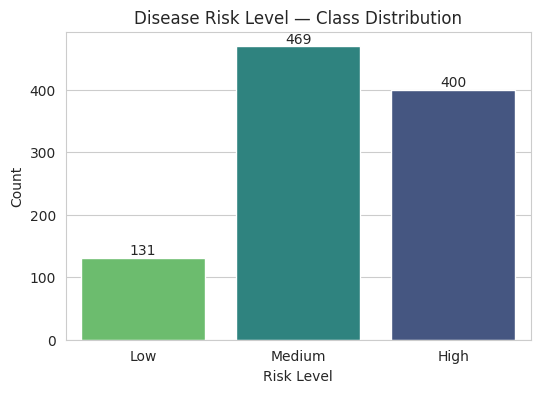

disease_risk_level
Medium    46.9
High      40.0
Low       13.1
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df_clean, x='disease_risk_level', hue='disease_risk_level',
                    order=['Low','Medium','High'], palette='viridis', legend=False)
plt.title('Disease Risk Level — Class Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

print(df_clean['disease_risk_level'].value_counts(normalize=True).round(3) * 100)


**Insight:** the classes are moderately imbalanced - Medium (46.9%) and High (40.0%)
dominate, Low is a clear minority (13.1%). This validates Task 03's choice of a **stratified**
split, and means Task 06 should report per-class Precision/Recall/F1 (or macro-F1), not just
overall accuracy - accuracy alone would be misleadingly high on this imbalance.

## 4.3 Distribution analysis - histograms

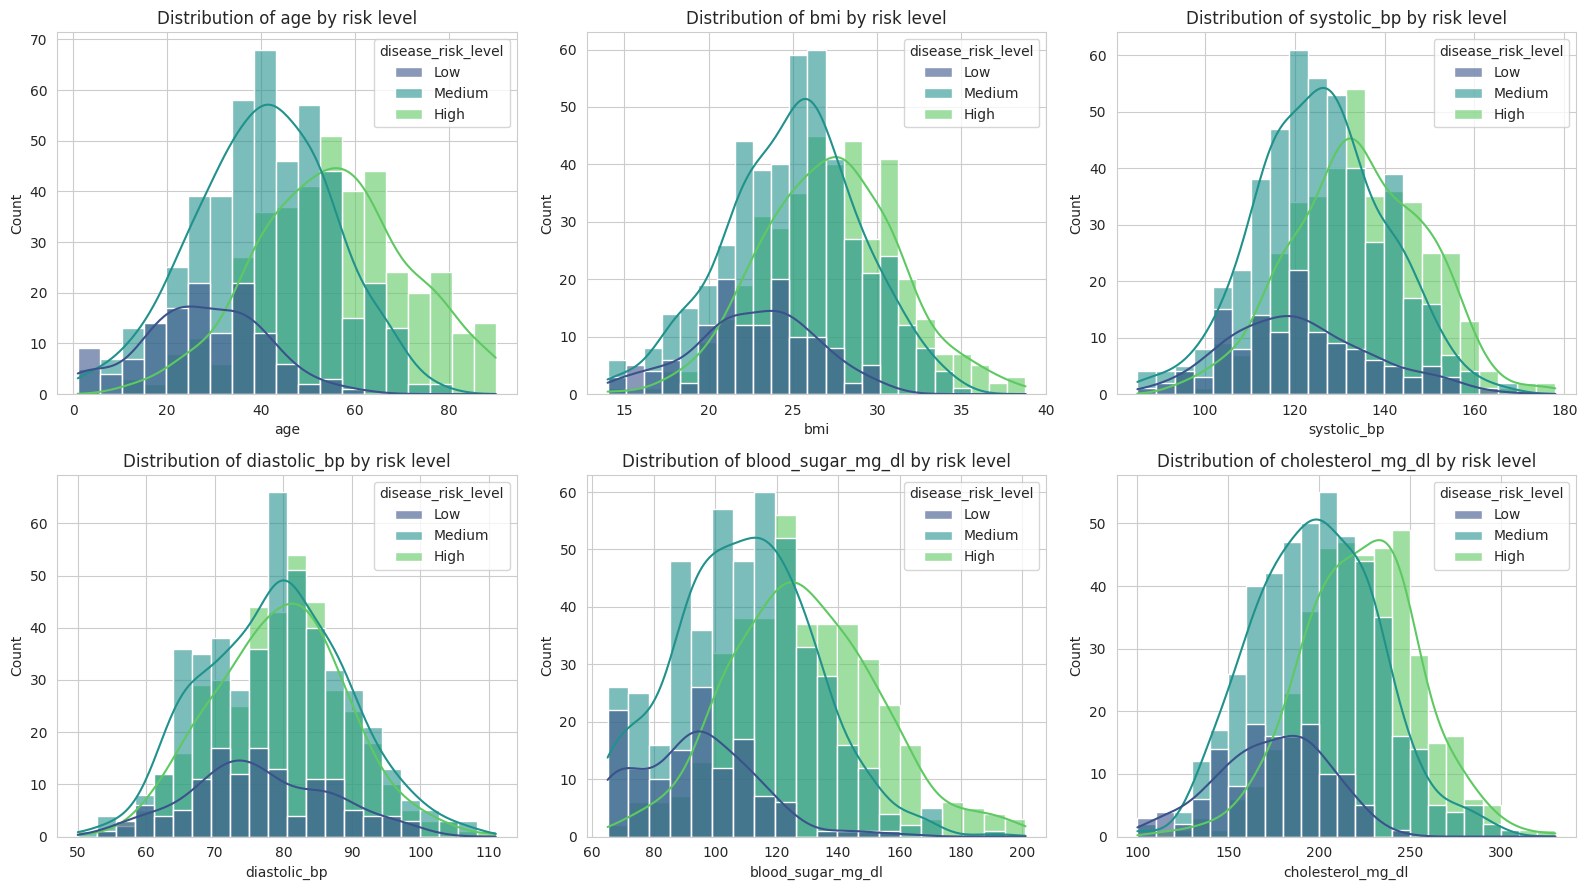

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
clinical_vars = ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl']

for ax, col in zip(axes.flat, clinical_vars):
    sns.histplot(data=df_clean, x=col, hue='disease_risk_level', hue_order=['Low','Medium','High'],
                 palette='viridis', kde=True, ax=ax, alpha=0.6)
    ax.set_title(f'Distribution of {col} by risk level')

plt.tight_layout()
plt.show()


**Insight:** `age` shows the cleanest separation - High-risk patients visibly cluster toward
the older end, Low-risk toward the younger end. `blood_sugar_mg_dl` and `cholesterol_mg_dl` show
a similar rightward shift for High risk, with more overlap than age. `diastolic_bp` shows the
most overlapping distributions across all three classes - the weakest predictor of the group.

## 4.4 Boxplots by risk level

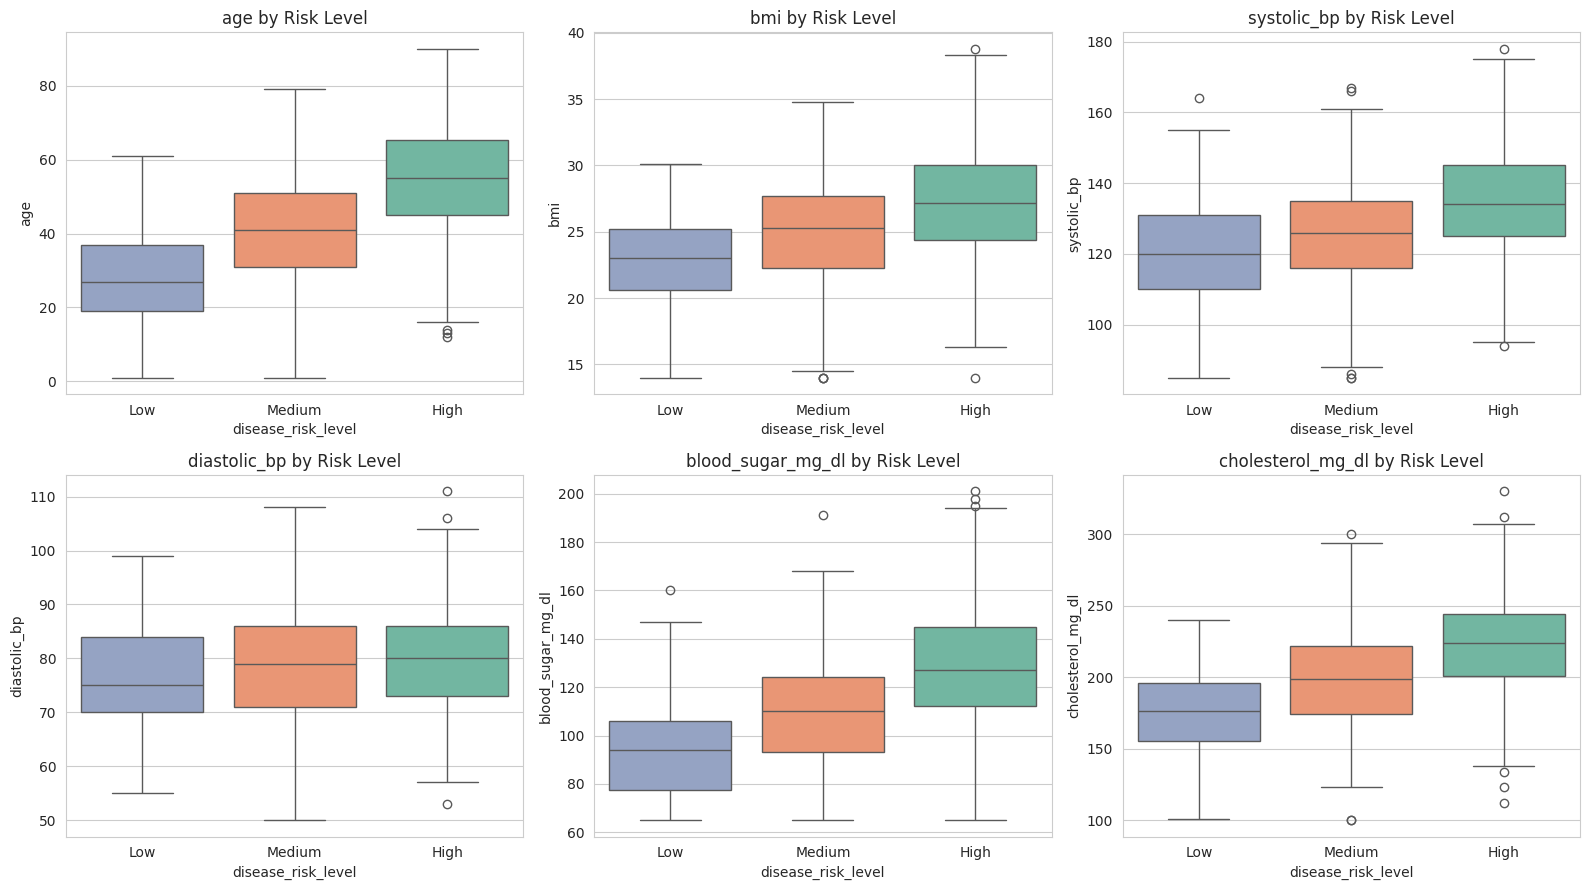

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, clinical_vars):
    sns.boxplot(data=df_clean, x='disease_risk_level', y=col, hue='disease_risk_level',
                order=['Low','Medium','High'], ax=ax, palette='Set2', legend=False)
    ax.set_title(f'{col} by Risk Level')

plt.tight_layout()
plt.show()


**Insight:** the median `age` box for High risk sits well above Low and Medium with minimal
overlap - the strongest single visual separator. `cholesterol_mg_dl` and `bmi` show upper-tail
outliers concentrated in the High-risk group, which is consistent with Task 03's decision to
**keep** rather than remove those outliers, since they carry class signal rather than being
noise.

## 4.5 Correlation analysis + heatmap

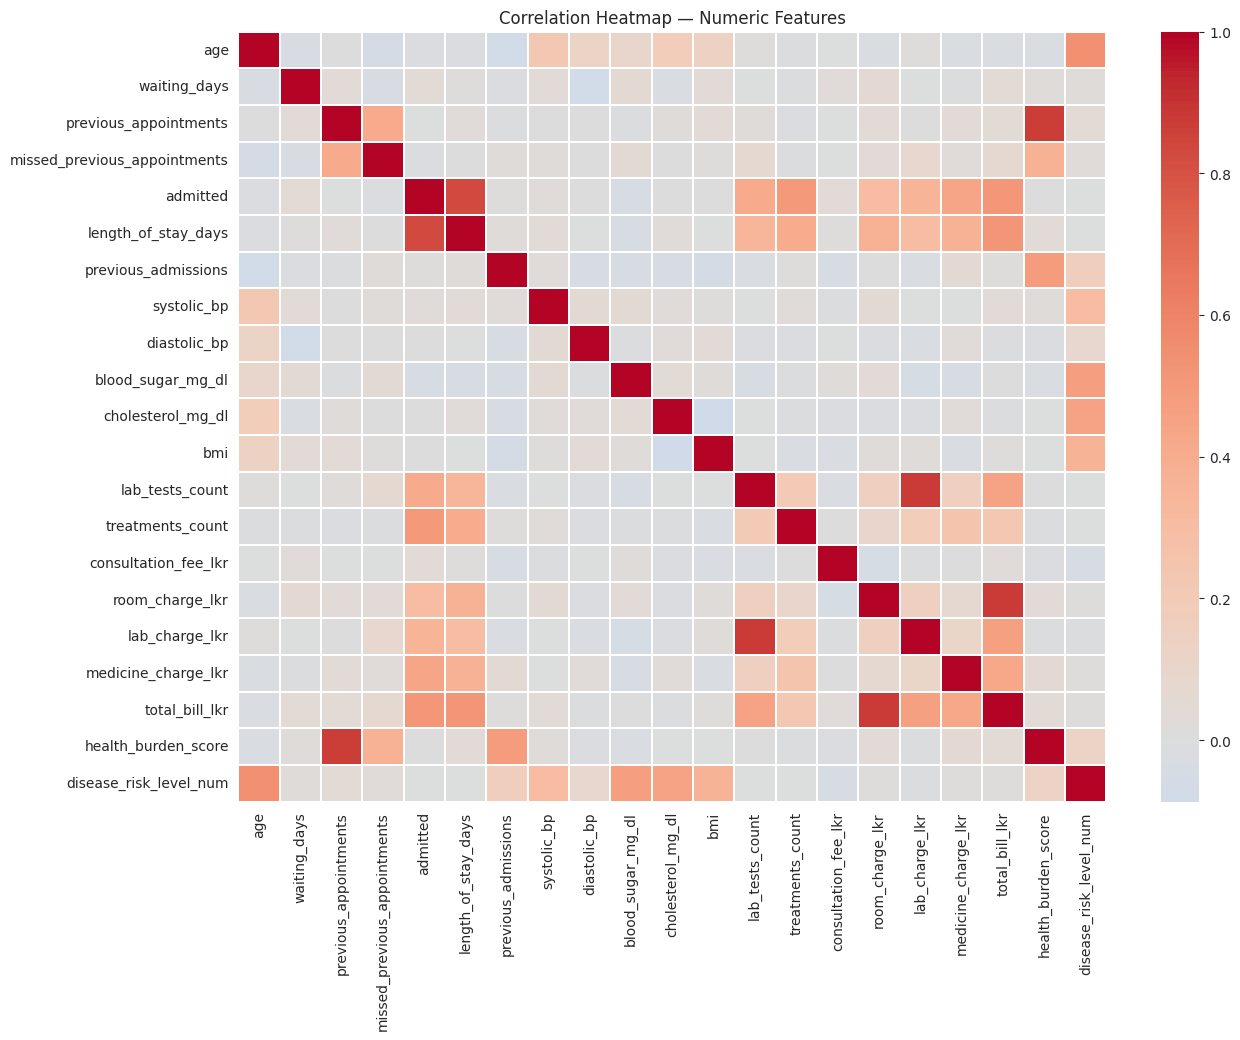

,disease_risk_level_num
age,0.537582
blood_sugar_mg_dl,0.474440
cholesterol_mg_dl,0.446766
bmi,0.359904
systolic_bp,0.310182
previous_admissions,0.171077
health_burden_score,0.127553
diastolic_bp,0.085260
previous_appointments,0.049035
missed_previous_appointments,0.027006


In [ ]:
numeric_df = df_clean.select_dtypes(include=[np.number]).drop(
    columns=['no_show', 'readmitted_30_days', 'record_id'], errors='ignore')
numeric_df['disease_risk_level_num'] = df_clean['disease_risk_level'].map({'Low':0,'Medium':1,'High':2})

plt.figure(figsize=(14, 10))
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap — Numeric Features')
plt.show()

corr_with_target = corr['disease_risk_level_num'].drop('disease_risk_level_num').sort_values(ascending=False)
corr_with_target


**Insight:** ranked by correlation with `disease_risk_level`, `age` (r ≈ 0.54) is by far the
strongest single predictor, followed by `blood_sugar_mg_dl` (≈0.47), `cholesterol_mg_dl`
(≈0.45), `bmi` (≈0.36), and `systolic_bp` (≈0.31). `previous_admissions`, `diastolic_bp`, and
`length_of_stay_days` are weak or negligible - this empirically confirms Task 03's decision to
drop the near-zero-correlation billing/operational columns.

## 4.6 Scatterplots - bivariate relationships

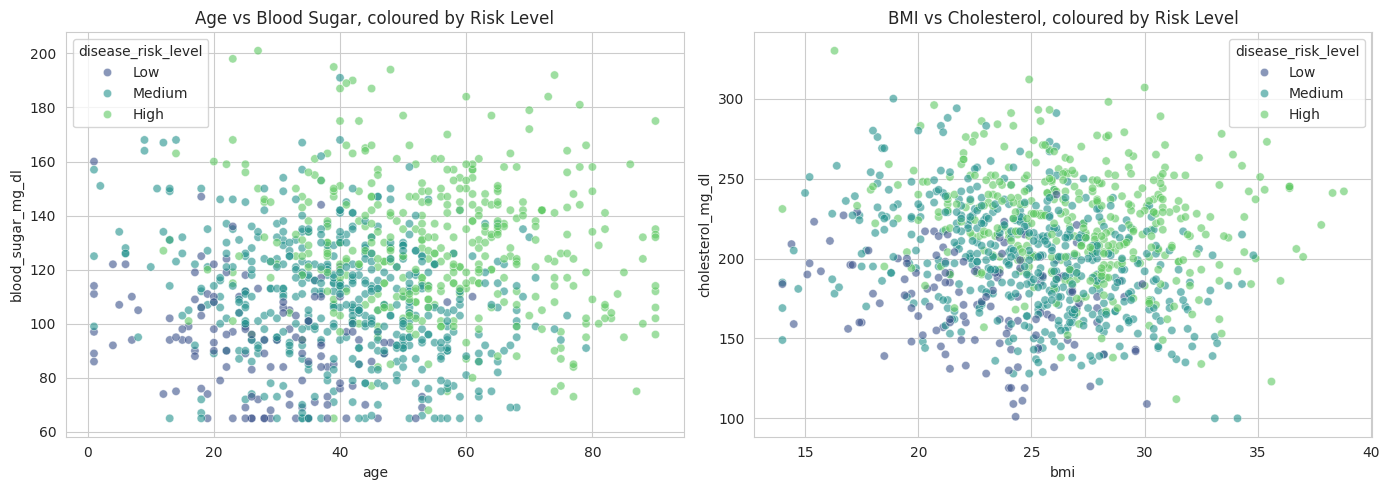

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df_clean, x='age', y='blood_sugar_mg_dl', hue='disease_risk_level',
                 hue_order=['Low','Medium','High'], palette='viridis', alpha=0.6, ax=axes[0])
axes[0].set_title('Age vs Blood Sugar, coloured by Risk Level')

sns.scatterplot(data=df_clean, x='bmi', y='cholesterol_mg_dl', hue='disease_risk_level',
                 hue_order=['Low','Medium','High'], palette='viridis', alpha=0.6, ax=axes[1])
axes[1].set_title('BMI vs Cholesterol, coloured by Risk Level')

plt.tight_layout()
plt.show()


**Insight:** in the age vs blood sugar panel, High-risk points concentrate in the
upper-right (older + higher blood sugar) while Low-risk clusters lower-left - the two variables
reinforce each other rather than acting independently. This kind of joint pattern is a signal
that tree-based models (Random Forest, XGBoost), which capture feature interactions natively,
may outperform a plain Logistic Regression on this dataset.

## 4.7 Pattern discovery - do the engineered categorical bands separate risk classes better than raw numbers?

In [ ]:
for col in ['bmi_category', 'blood_sugar_category', 'age_group', 'bp_category']:
    ct = pd.crosstab(df_clean[col], df_clean['disease_risk_level'], normalize='index')[['Low','Medium','High']] * 100
    print(f"\n{col}:")
    print(ct.round(1))



bmi_category:
disease_risk_level   Low  Medium  High
bmi_category                          
Normal              20.2    50.0  29.8
Obese                0.6    33.5  65.8
Overweight           8.4    47.6  43.9
Underweight         32.1    57.1  10.7

blood_sugar_category:
disease_risk_level     Low  Medium  High
blood_sugar_category                    
Diabetic               1.2    33.7  65.0
Normal                30.2    55.9  13.9
Prediabetic           10.3    51.2  38.6

age_group:
disease_risk_level   Low  Medium  High
age_group                             
Adult                9.5    54.2  36.3
Child               46.7    50.0   3.3
Senior               0.5    20.8  78.7
Young Adult         34.7    51.8  13.5

bp_category:
disease_risk_level   Low  Medium  High
bp_category                           
Elevated            16.4    51.6  32.0
Hypertensive         9.6    44.9  45.5
Normal              25.6    51.8  22.6


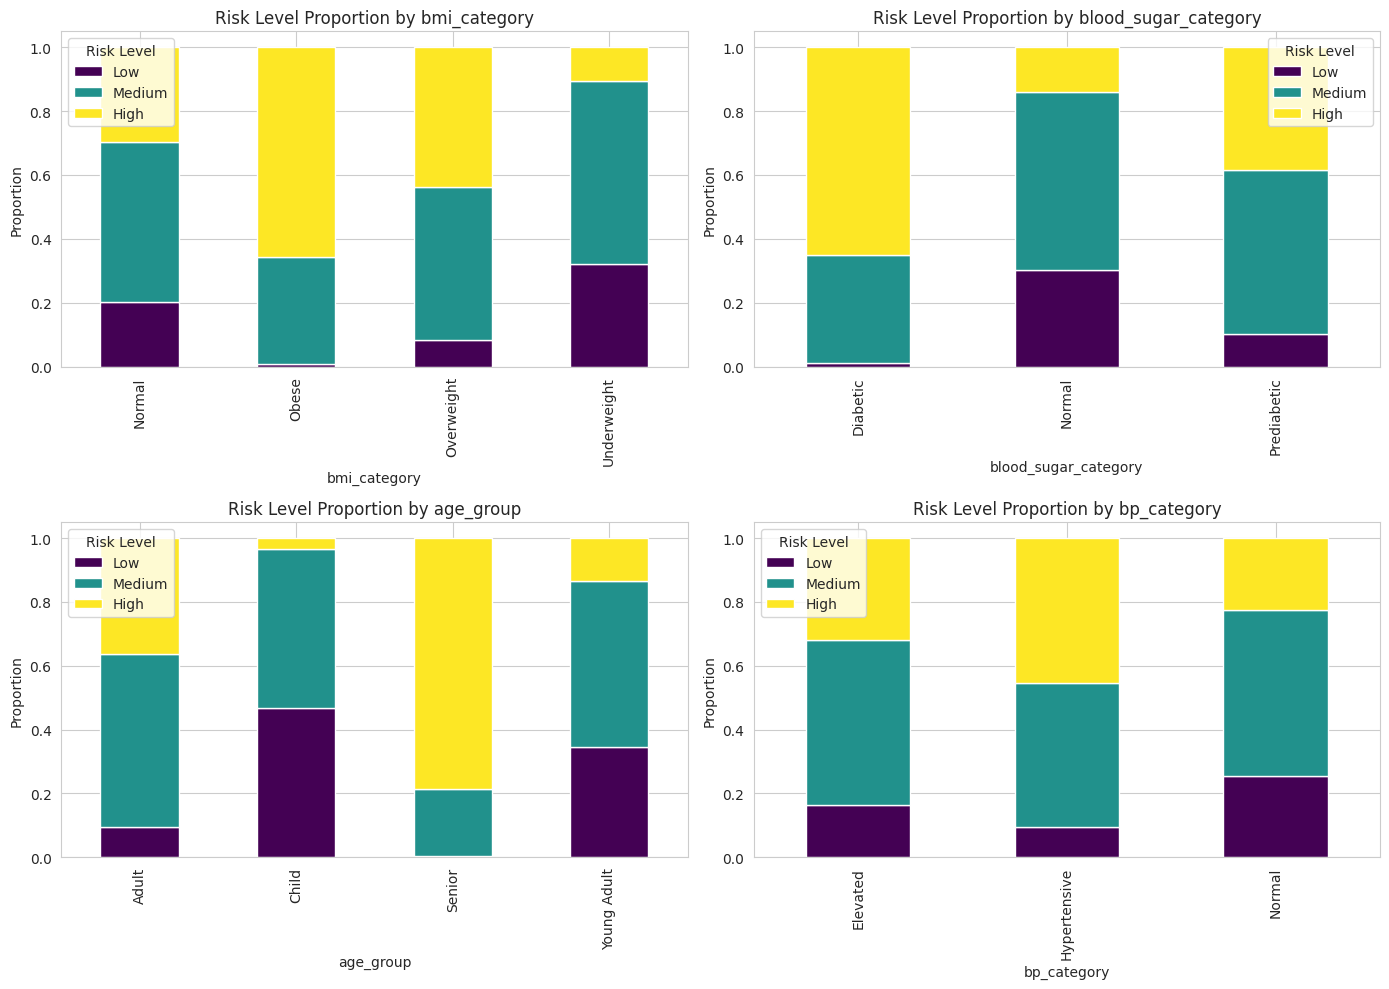

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_cols = ['bmi_category', 'blood_sugar_category', 'age_group', 'bp_category']

for ax, col in zip(axes.flat, cat_cols):
    ct = pd.crosstab(df_clean[col], df_clean['disease_risk_level'], normalize='index')[['Low','Medium','High']]
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
    ax.set_title(f'Risk Level Proportion by {col}')
    ax.set_ylabel('Proportion')
    ax.legend(title='Risk Level')

plt.tight_layout()
plt.show()


**Insight - the strongest pattern-discovery finding in this notebook:** the engineered bands
separate risk far more cleanly than the raw numbers did above. Obese patients are High-risk
~66% of the time vs ~11% for Underweight. Diabetic patients are High-risk ~65% of the time vs
~14% for Normal blood sugar. Age group shows the sharpest split of all - Seniors are High-risk
~79% of the time vs ~3% for Children. `bp_category` is the weakest of the four engineered bands,
showing a real but much shallower gradient. This validates Task 03's feature engineering: these
categorical bands are likely to be high-value predictors, more so than their raw continuous
sources alone.

## 4.8 Department vs risk level (operational pattern check)

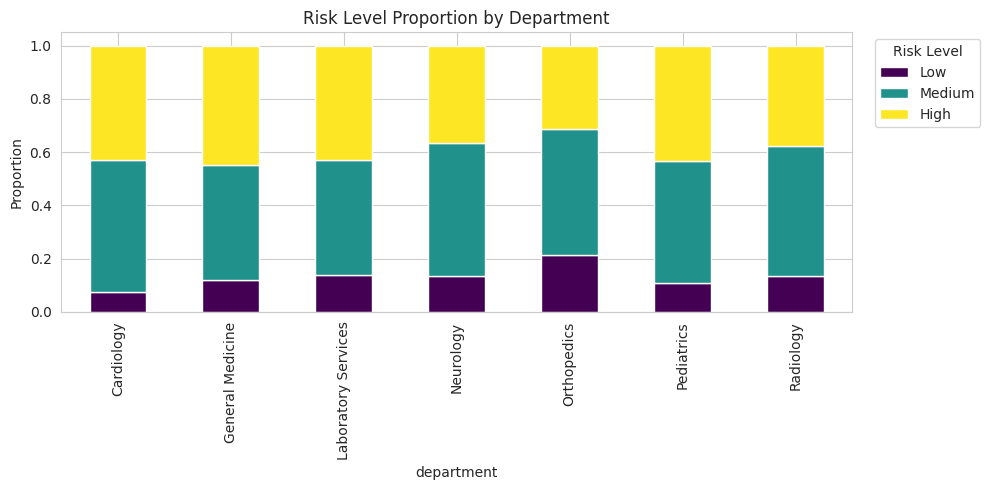

disease_risk_level,Low,Medium,High
department,,,
Cardiology,7.6,49.4,43.0
General Medicine,11.9,43.4,44.7
Laboratory Services,13.8,43.1,43.1
Neurology,13.5,50.0,36.5
Orthopedics,21.3,47.5,31.2
Pediatrics,10.9,45.7,43.5
Radiology,13.6,48.6,37.9


In [ ]:
dept_risk = pd.crosstab(df_clean['department'], df_clean['disease_risk_level'], normalize='index')[['Low','Medium','High']]

plt.figure(figsize=(10, 5))
dept_risk.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Risk Level Proportion by Department')
plt.ylabel('Proportion')
plt.legend(title='Risk Level', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

(dept_risk * 100).round(1)


## 4.9 Summary of EDA insights (for the Technical Report)

| Finding | Evidence | Implication for later tasks |
|---|---|---|
| Age is the strongest predictor | r ≈ 0.54; mean age rises Low→Medium→High | Should be a top feature in every Task 05 model; expect high SHAP importance in Task 07 |
| Engineered categorical bands outperform raw numeric separation | Obese→~66% High, Diabetic→~65% High, Senior→~79% High | Validates Task 03's feature engineering; these bands are high-value predictors |
| Class imbalance: Low 13.1% / Medium 46.9% / High 40.0% | Section 4.2 | Stratified split was correct; Task 06 should report per-class/macro metrics, not just accuracy |
| Billing and operational columns (`total_bill_lkr`, `lab_tests_count`, `treatments_count`, `waiting_days`, `length_of_stay_days`) carry near-zero correlation with disease risk | Section 4.5 | Confirms Task 03's decision to drop them from the feature set |
| `room_type` missingness was structural (tied to `admitted` status), not random | Task 03, Section 3.2 | Handled with cause-specific imputation rather than a single blanket rule |
